# Cas 1 et 2 — Explicabilité des modèles (Maladie rénale chronique)

Ce notebook implémente :
- **Cas 1** : Interprétabilité intrinsèque — régression logistique et arbre de décision.
- **Cas 2** : Explicabilité post-hoc — SVM comme boîte noire, puis LIME et SHAP.

Données : jeu UCI *Chronic Kidney Disease* (CKD).

In [94]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 40

# Dossier pour enregistrer toutes les figures
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Chargement et préparation des données

In [95]:
# Chargement (depuis notebooks/ : kidney_disease.csv)
df = pd.read_csv('kidney_disease.csv')
df.drop('id', axis=1, inplace=True)
df.columns = [
    'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
    'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count',
    'red_blood_cell_count', 'hypertension', 'diabetes_mellitus',
    'coronary_artery_disease', 'appetite', 'peda_edema', 'aanemia', 'class'
]

# Colonnes numériques stockées en object
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

print(df.shape)
df.head()
df.info()
df.describe()

(400, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin     

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [96]:
# Nettoyage des valeurs catégorielles incorrectes
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace(to_replace={'\tno': 'no', '\tyes': 'yes', ' yes': 'yes'})
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace='\tno', value='no')
df['class'] = df['class'].replace(to_replace={'ckd\t': 'ckd', 'notckd': 'not ckd'})
# Cible binaire : 0 = ckd, 1 = not ckd
df['class'] = df['class'].map({'ckd': 0, 'not ckd': 1})
df['class'] = pd.to_numeric(df['class'], errors='coerce')
# Suppression des lignes avec class NaN (après map)
df = df.dropna(subset=['class'])
num_cols = [c for c in df.columns if df[c].dtype in ('float64', 'int64') and c != 'class']
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
print('num_cols:', len(num_cols), '| cat_cols:', len(cat_cols))

num_cols: 14 | cat_cols: 10


In [97]:
# Imputation : KNN pour les numériques, mode pour les catégorielles
knn_imputer = KNNImputer(n_neighbors=5)
df[num_cols] = knn_imputer.fit_transform(df[num_cols])
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
print('Valeurs manquantes restantes:', df.isna().sum().sum())

Valeurs manquantes restantes: 0


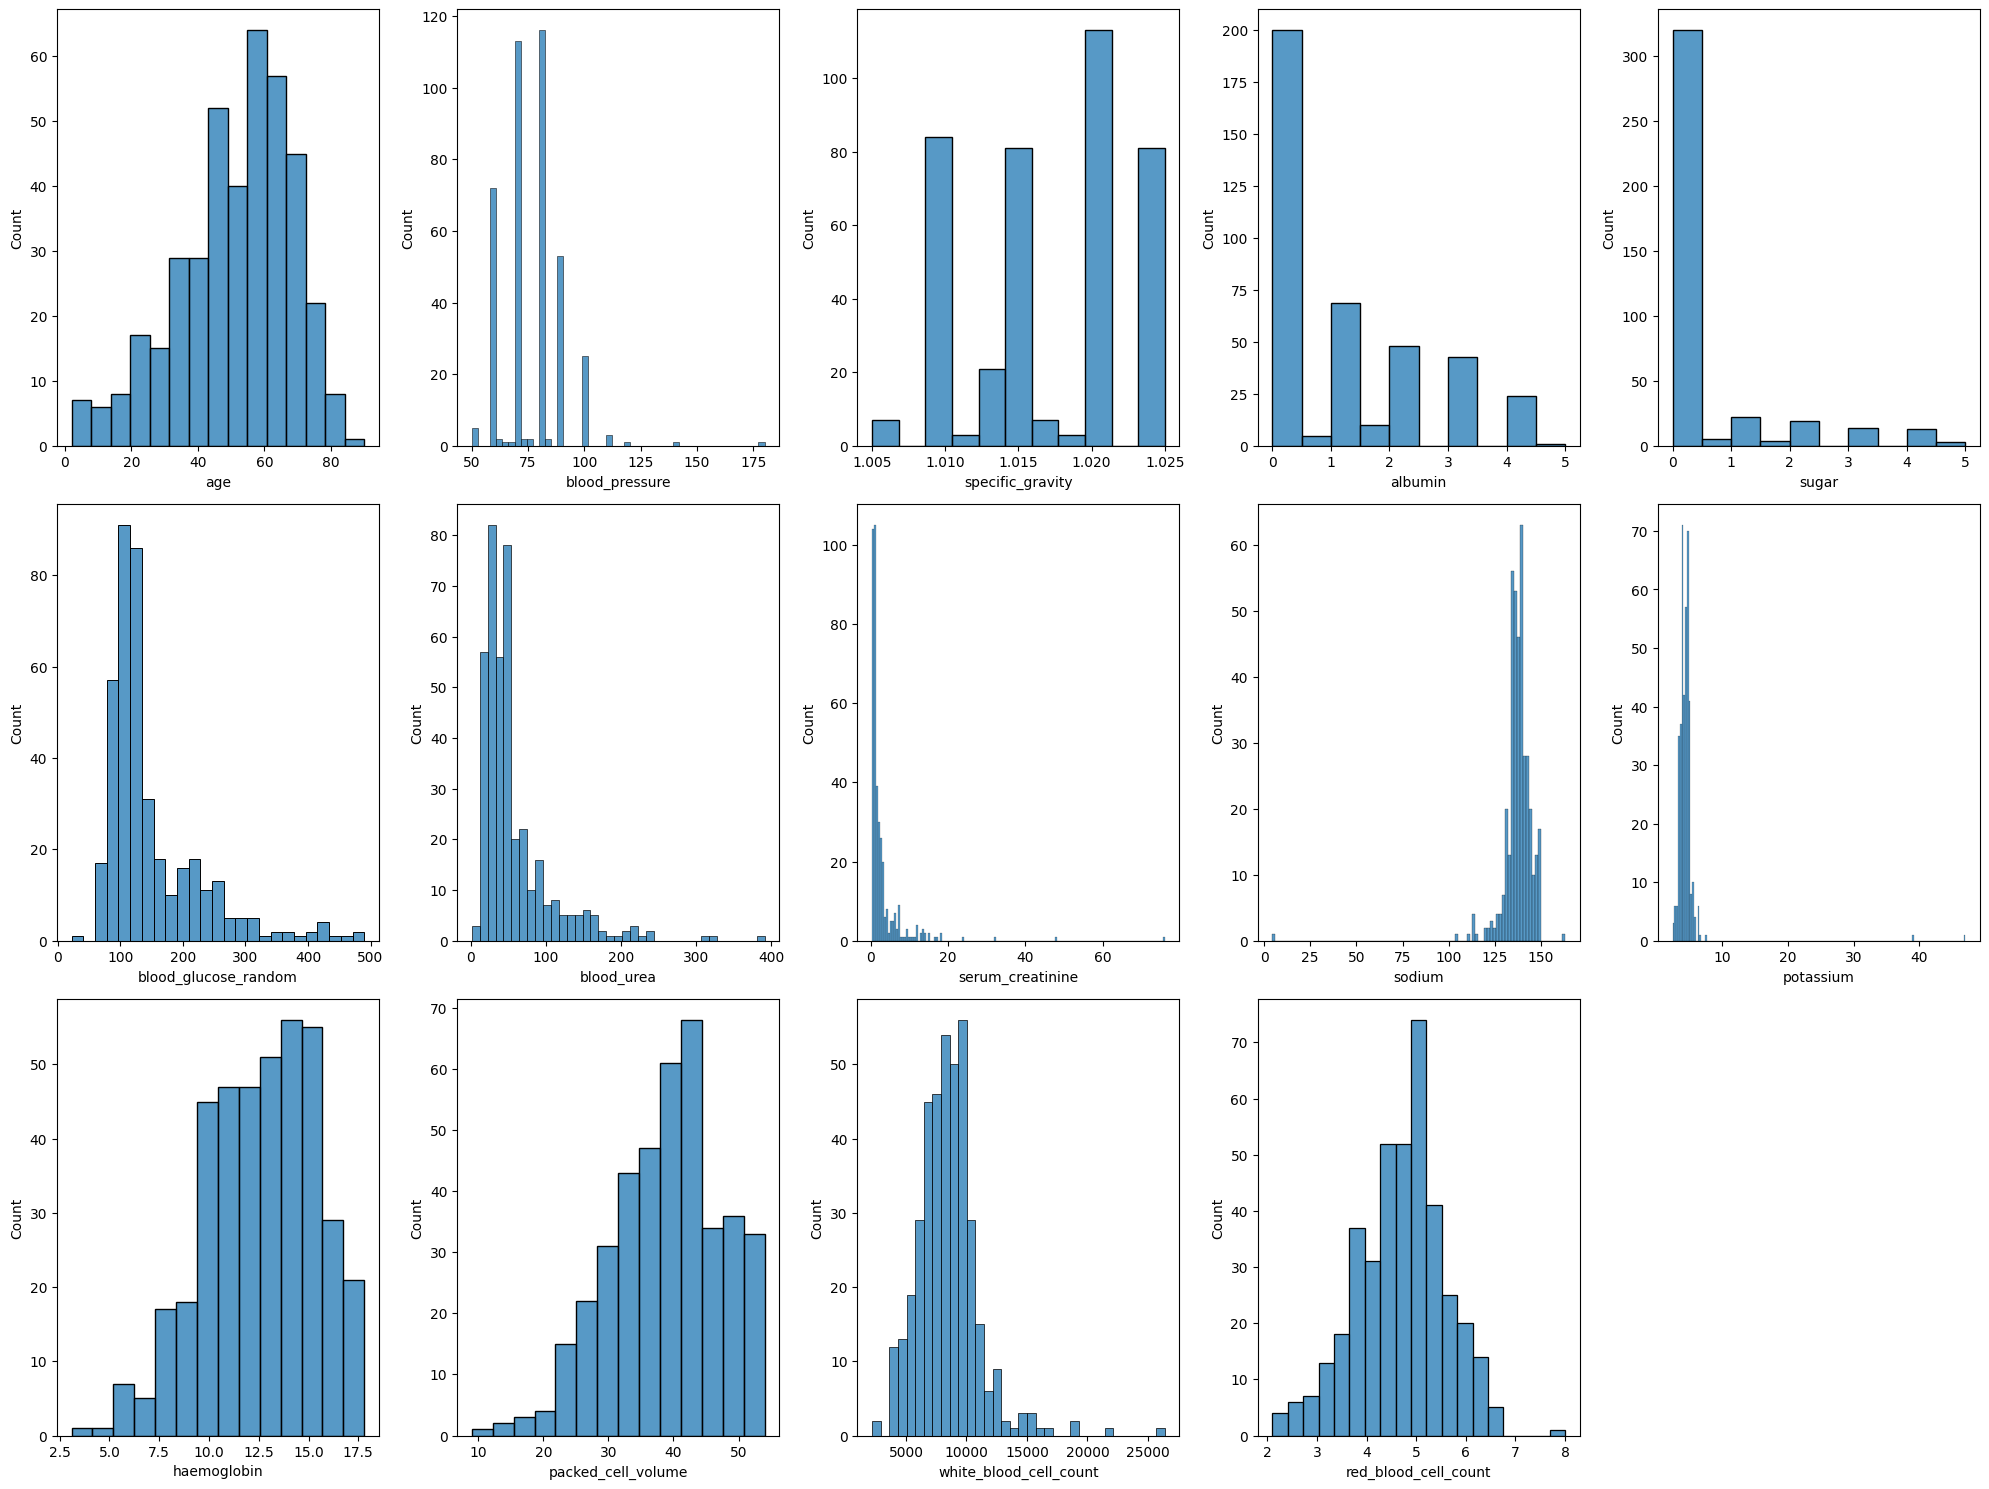

In [98]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        vals = np.asarray(df[column].dropna(), dtype=float).ravel()
        sns.histplot(x=vals, kde=False, ax=ax)
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_distributions_numeriques.png'), bbox_inches='tight', dpi=150)
plt.show()

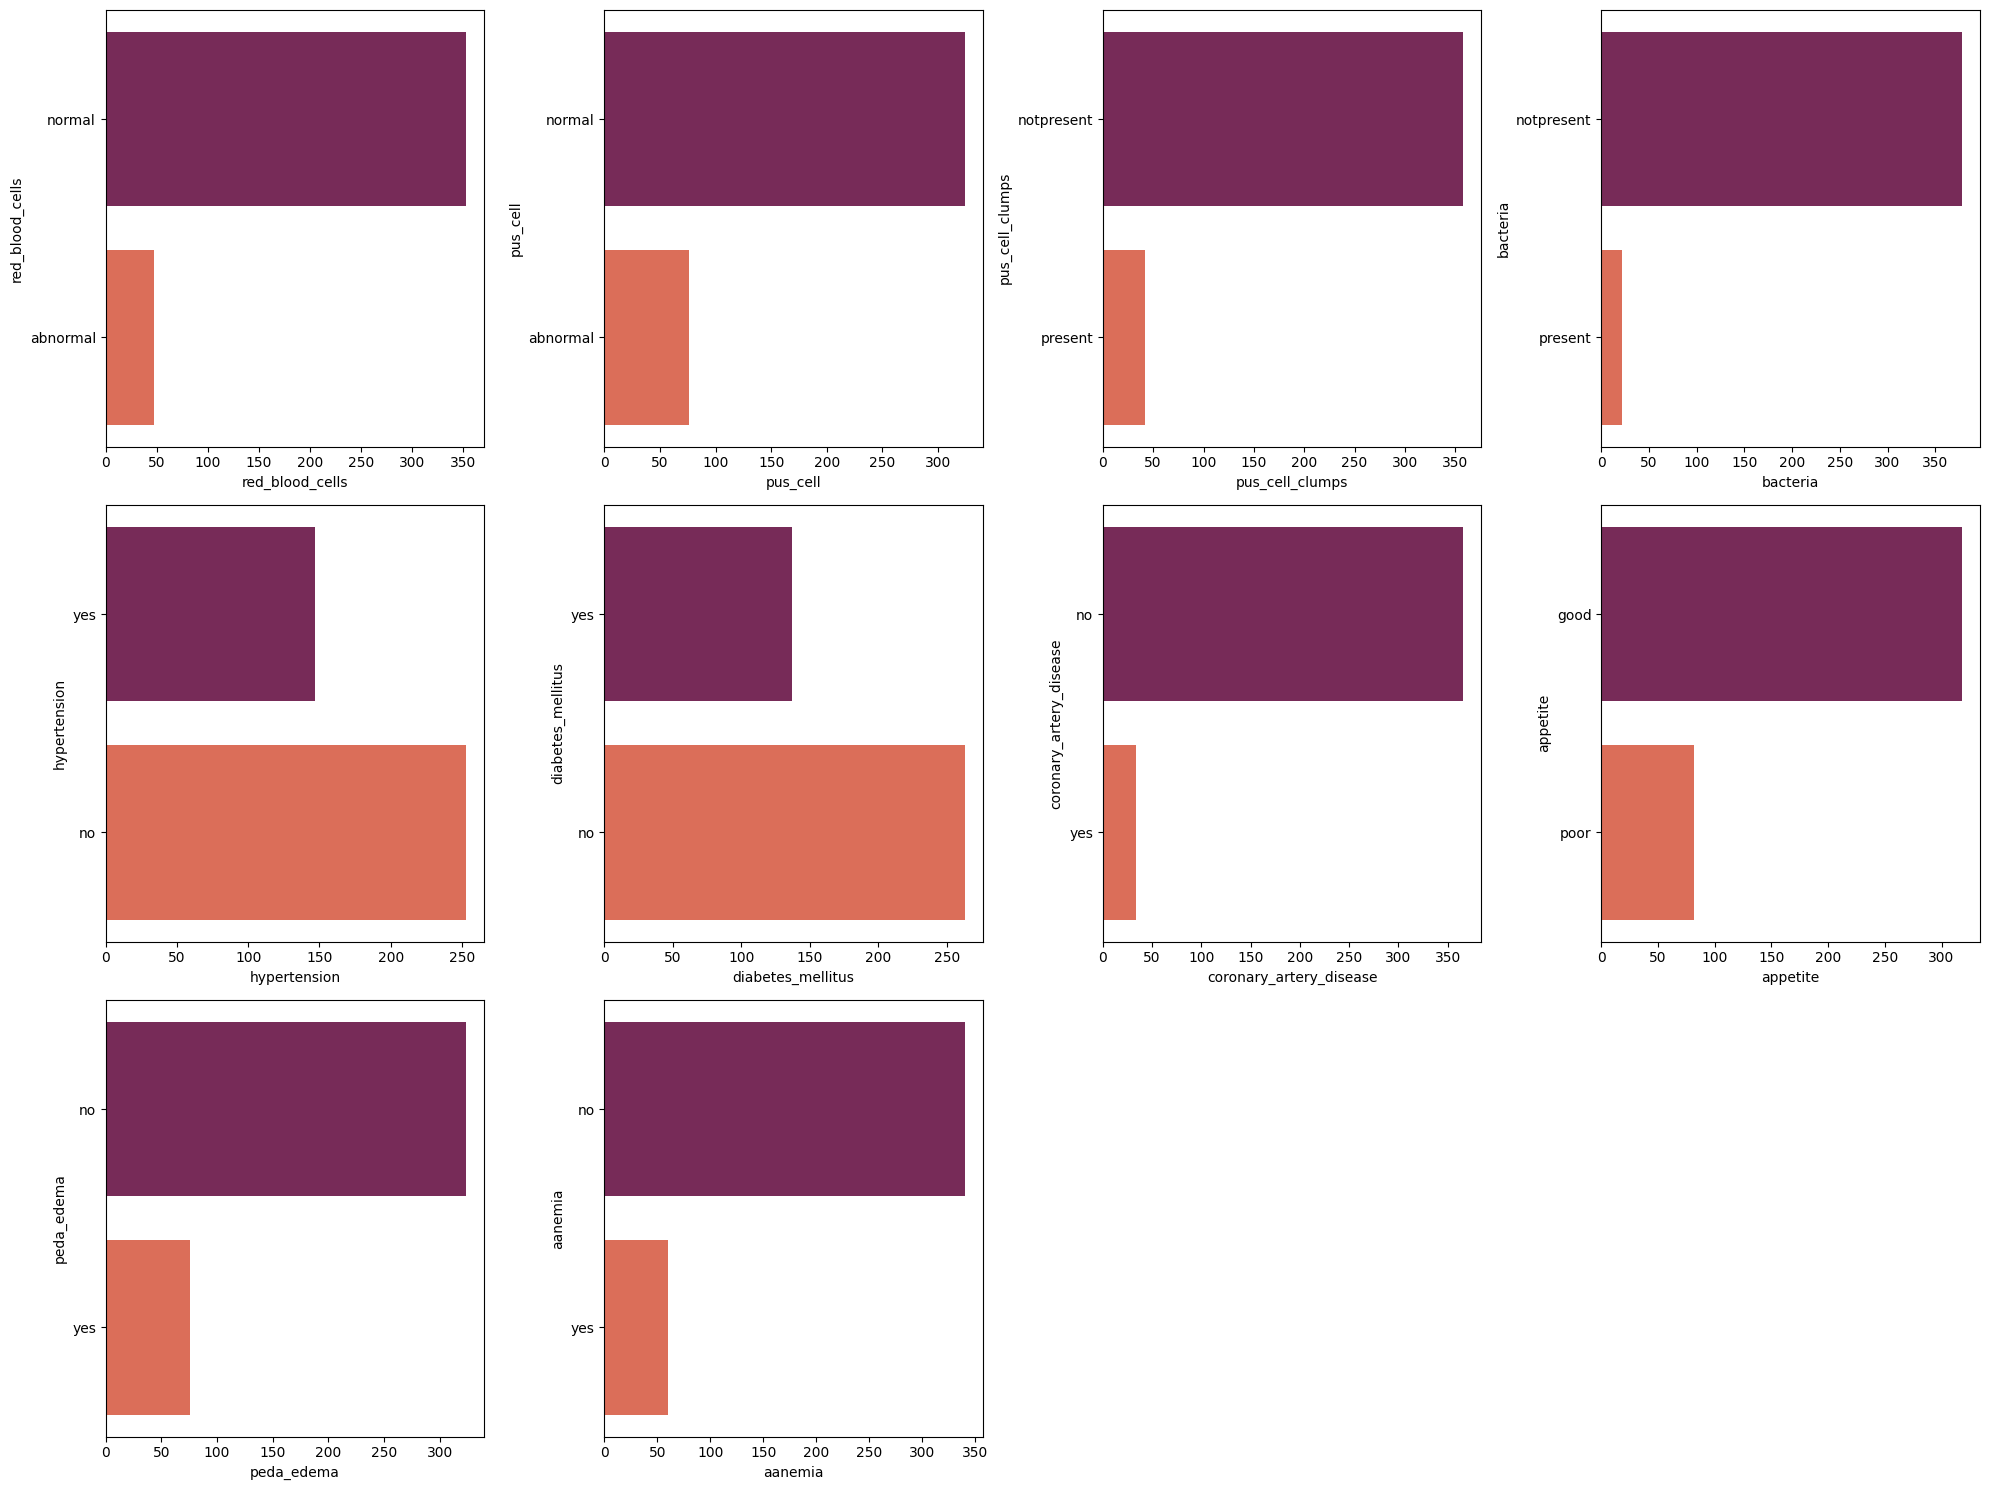

In [99]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in cat_cols:
    if plotnumber <= 11:
        ax = plt.subplot(3, 4, plotnumber)
        sns.countplot(df[column], palette = 'rocket')
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_categories_countplot.png'), bbox_inches='tight', dpi=150)
plt.show()

In [100]:
# Encodage des variables catégorielles (LabelEncoder)
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
# Matrice de features et cible
X = df.drop(columns=['class'])
y = df['class']
feature_names = X.columns.tolist()
print('X shape:', X.shape, '| y shape:', y.shape)
X.head()

X shape: (400, 24) | y shape: (400,)


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,15.4,44.0,7800.0,5.20,1,1,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,113.0,...,11.3,38.0,6000.0,4.96,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,9.6,31.0,7500.0,3.80,0,1,0,1,0,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.90,1,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,11.6,35.0,7300.0,4.60,0,0,0,0,0,0


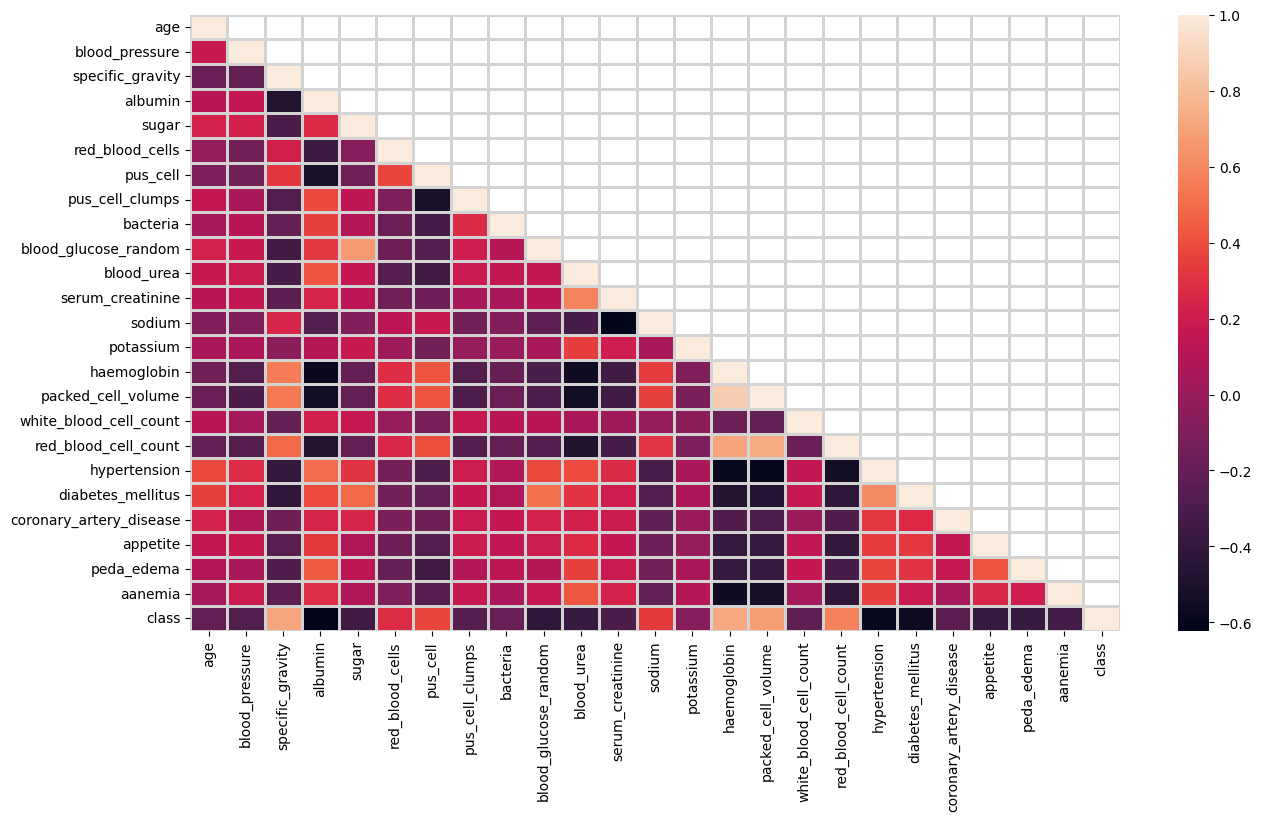

In [101]:
plt.figure(figsize = (15, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # masquer le triangle supérieur
sns.heatmap(corr, mask=mask, annot=False, linewidths=2, linecolor='lightgrey')
plt.savefig(os.path.join(FIG_DIR, '03_heatmap_corr.png'), bbox_inches='tight', dpi=150)
plt.show()

In [102]:
# Split stratifié (70% train / 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
# SMOTE sur l'ensemble d'entraînement
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('Train (après SMOTE):', X_train_smote.shape, '| Test:', X_test.shape)
print('Distribution train SMOTE:', pd.Series(y_train_smote).value_counts().to_dict())

Train (après SMOTE): (350, 24) | Test: (120, 24)
Distribution train SMOTE: {0: 175, 1: 175}


In [103]:
# StandardScaler (fit sur train SMOTE, transform train et test)
scaler = StandardScaler()
# SMOTE peut retourner un ndarray : on reconstruit un DataFrame avec les noms de colonnes
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_smote),
    columns=feature_names
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)
# Pour LIME/SHAP on aura besoin des noms de colonnes
print('Données prêtes. X_train_scaled shape:', X_train_scaled.shape)

Données prêtes. X_train_scaled shape: (350, 24)


## 2. Cas 1 — Interprétabilité intrinsèque

Modèles « glass-box » : les paramètres ou la structure du modèle sont directement lisibles.

### 2.1 Régression logistique

Les coefficients donnent l'effet de chaque variable sur la prédiction (tendance vers le risque CKD).

In [104]:
# Régression logistique (pénalisée)
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train_scaled, y_train_smote)
y_pred_lr = lr.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('AUC:', roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred_lr))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.9833333333333333
AUC: 0.9994074074074074
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        75
           1       0.98      0.98      0.98        45

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120

Confusion matrix:
 [[74  1]
 [ 1 44]]


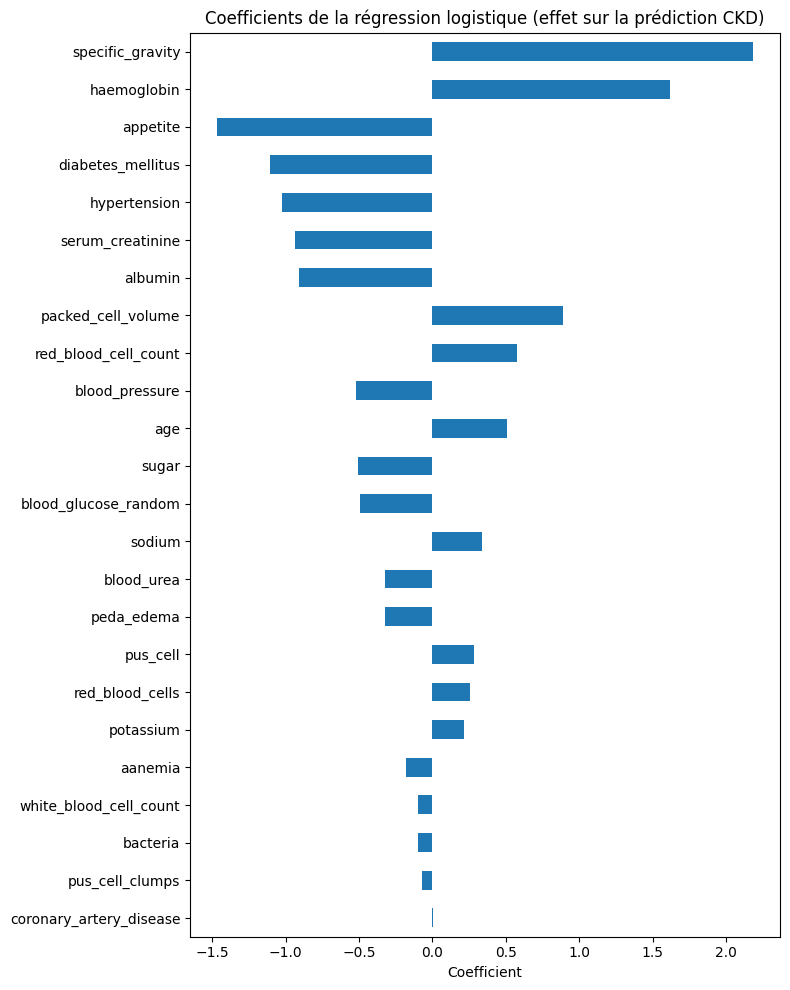

Variables avec le plus fort effet positif (risque CKD): ['hypertension', 'diabetes_mellitus', 'appetite', 'haemoglobin', 'specific_gravity']
Variables avec le plus fort effet négatif (protecteur): ['coronary_artery_disease', 'pus_cell_clumps', 'bacteria', 'white_blood_cell_count', 'aanemia']


In [105]:
# Coefficients : interprétation directe
coef = pd.Series(lr.coef_.ravel(), index=feature_names)
coef = coef.reindex(coef.abs().sort_values(ascending=True).index)
fig, ax = plt.subplots(figsize=(8, 10))
coef.plot(kind='barh', ax=ax)
ax.set_title('Coefficients de la régression logistique (effet sur la prédiction CKD)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_lr_coefficients.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Variables avec le plus fort effet positif (risque CKD):', coef.tail(5).index.tolist())
print('Variables avec le plus fort effet négatif (protecteur):', coef.head(5).index.tolist())

### 2.2 Arbre de décision

Arbre limité en profondeur (max_depth=4) pour rester lisible ; chaque chemin racine → feuille donne une règle « SI … ALORS ».

In [106]:
# Arbre de décision (profondeur limitée pour interprétabilité)
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train_smote)
y_pred_dt = dt.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print('AUC:', roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred_dt))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.9333333333333333
AUC: 0.9487407407407409
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        75
           1       0.91      0.91      0.91        45

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.93       120
weighted avg       0.93      0.93      0.93       120

Confusion matrix:
 [[71  4]
 [ 4 41]]


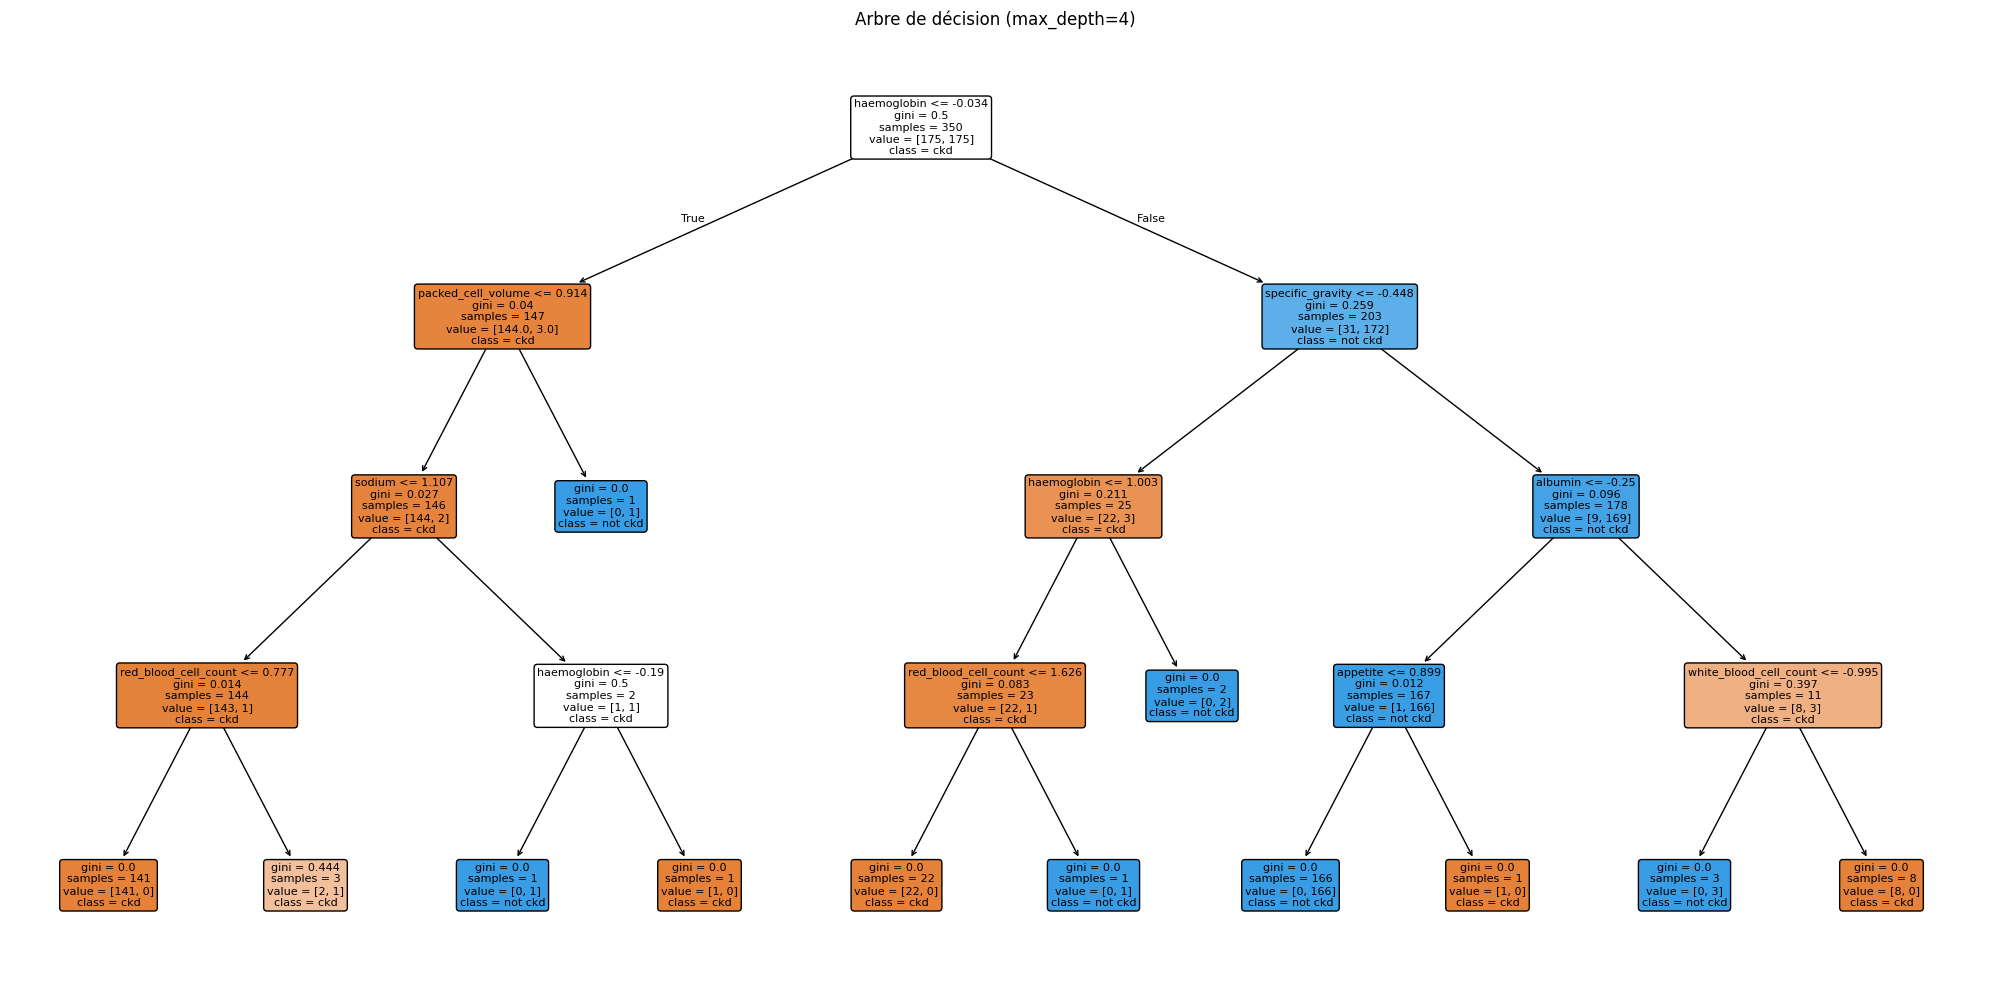

In [107]:
# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=feature_names, class_names=['ckd', 'not ckd'],
          filled=True, rounded=True, ax=ax, fontsize=8)
ax.set_title('Arbre de décision (max_depth=4)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_arbre_decision.png'), bbox_inches='tight', dpi=150)
plt.show()

In [108]:
# Exemple de règles extraites : importance des variables (Gini)
imp = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)
print('Importance des variables (arbre):')
print(imp.head(8))
print('\nExemple de règle (lecture de l\'arbre) : SI specific_gravity <= seuil ET haemoglobin <= seuil ALORS forte probabilité CKD.')

Importance des variables (arbre):
haemoglobin               0.696492
specific_gravity          0.173678
albumin                   0.061832
white_blood_cell_count    0.025127
red_blood_cell_count      0.014774
appetite                  0.011447
packed_cell_volume        0.011127
sodium                    0.005523
dtype: float64

Exemple de règle (lecture de l'arbre) : SI specific_gravity <= seuil ET haemoglobin <= seuil ALORS forte probabilité CKD.


## 3. Cas 2 — Explicabilité post-hoc (modèles opaques)

On utilise un SVM à noyau comme boîte noire, puis LIME (explication locale) et SHAP (local + global).

### 3.1 Modèle boîte noire : SVM

SVC avec noyau RBF et probability=True pour exposer predict_proba (nécessaire pour LIME/SHAP).

In [109]:
# SVM à noyau RBF (modèle opaque)
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train_smote)
y_pred_svm = svm.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred_svm))
print('AUC:', roc_auc_score(y_test, svm.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred_svm))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.975
AUC: 0.9991111111111112
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        75
           1       0.96      0.98      0.97        45

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120

Confusion matrix:
 [[73  2]
 [ 1 44]]


### 3.2 LIME (explication locale)

LIME approxime le modèle opaque par un modèle interprétable (ex. régression linéaire) autour d'une instance. Limite : les explications peuvent varier d'une exécution à l'autre (instabilité).

In [110]:
# Installer lime et shap si nécessaire
%pip install lime shap -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [111]:
# LIME : prédicteur = proba classe positive (CKD = 0 dans notre encodage : classe 0 = ckd)
# On explique la probabilité de la classe 0 (ckd) pour LIME
def predict_proba_ckd(X_arr):
    return svm.predict_proba(X_arr)[:, 0]  # proba classe 0 = ckd

try:
    import lime
    import lime.lime_tabular
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call(["pip", "install", "lime", "-q"])
    import lime
    import lime.lime_tabular
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled.values,
    feature_names=feature_names,
    class_names=['ckd', 'not ckd'],
    mode='regression',
    random_state=RANDOM_STATE
)
# Instance à expliquer : un patient du test (ex. premier prédit comme CKD avec forte proba)
idx_instance = (svm.predict_proba(X_test_scaled)[:, 0] > 0.9).argmax()
if not (svm.predict_proba(X_test_scaled)[:, 0] > 0.9).any():
    idx_instance = 0
instance = X_test_scaled.iloc[idx_instance].values
exp_lime = explainer_lime.explain_instance(instance, predict_proba_ckd, num_features=10)
exp_lime.show_in_notebook(show_table=True)

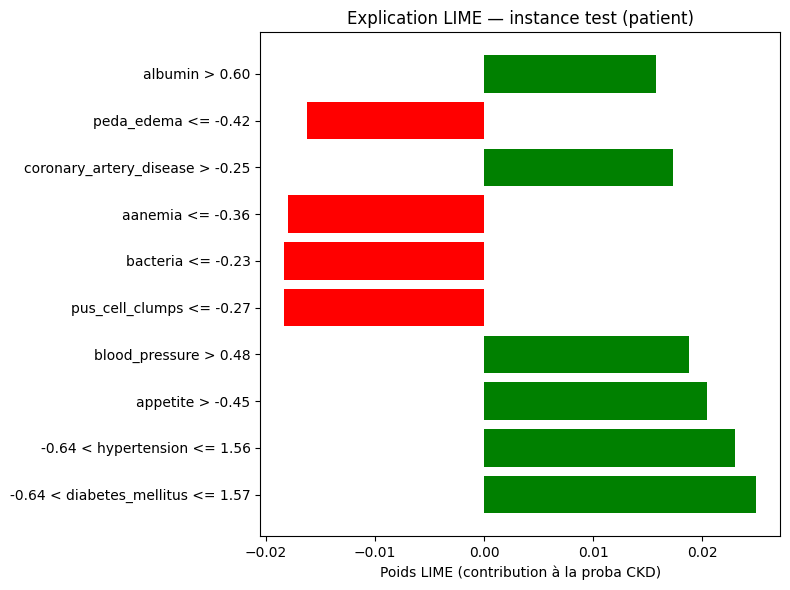

In [112]:
# Diagramme à barres des poids LIME pour la même instance
lime_weights = exp_lime.as_list()
names = [x[0] for x in lime_weights]
weights = [x[1] for x in lime_weights]
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(names))
colors = ['green' if w > 0 else 'red' for w in weights]
ax.barh(y_pos, weights, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel('Poids LIME (contribution à la proba CKD)')
ax.set_title('Explication LIME — instance test (patient)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_lime_local.png'), bbox_inches='tight', dpi=150)
plt.show()

### 3.3 SHAP (explications locales et globales)

SHAP repose sur les valeurs de Shapley (théorie des jeux). Additivité exacte et stabilité des explications. KernelExplainer est agnostique au modèle (coût computationnel plus élevé).

In [113]:
# SHAP : KernelExplainer (modèle agnostique) — background = échantillon du train
try:
    import shap
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call(["pip", "install", "shap", "-q"])
    import shap
# Prédicteur à une sortie (proba classe 0 = ckd) pour obtenir des SHAP par feature (24), pas par classe (2)
def predict_proba_ckd_shap(X):
    return svm.predict_proba(X)[:, 0]
background = X_train_scaled.sample(50, random_state=RANDOM_STATE)
explainer_shap = shap.KernelExplainer(
    predict_proba_ckd_shap,
    background,
    link='logit'
)

100%|██████████| 1/1 [00:00<00:00, 26.64it/s]


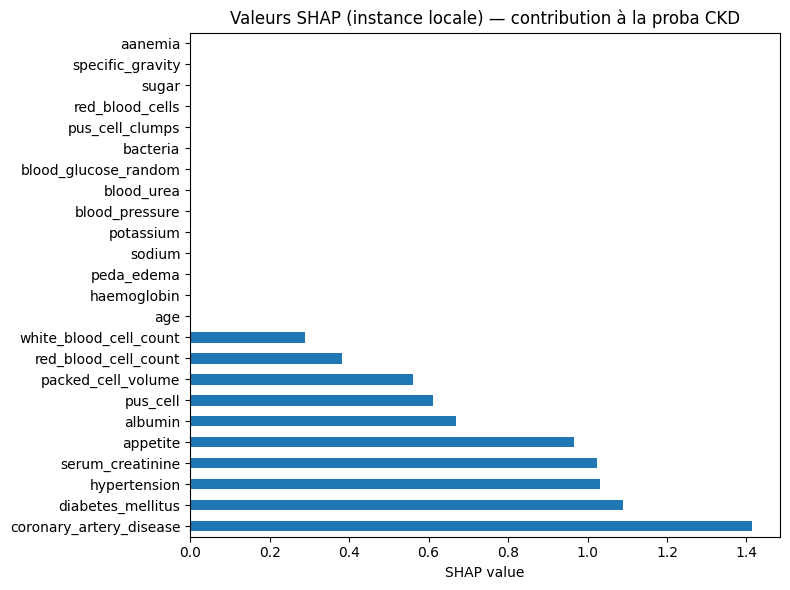

In [114]:
# Explication locale : même instance que pour LIME
# Avec predict_proba_ckd_shap, shap_values a shape (n_samples, n_features)
shap_values_one = explainer_shap.shap_values(X_test_scaled.iloc[idx_instance:idx_instance+1], nsamples=100)
shap_local = np.array(shap_values_one).flatten()  # (1, 24) -> (24,)
assert len(shap_local) == len(feature_names), "SHAP length mismatch"
fig, ax = plt.subplots(figsize=(8, 6))
s = pd.Series(shap_local, index=feature_names)
s = s.reindex(s.abs().sort_values(ascending=False).index)
s.plot(kind='barh', ax=ax)
ax.set_title('Valeurs SHAP (instance locale) — contribution à la proba CKD')
ax.set_xlabel('SHAP value')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_shap_local.png'), bbox_inches='tight', dpi=150)
plt.show()

100%|██████████| 50/50 [00:01<00:00, 28.35it/s]


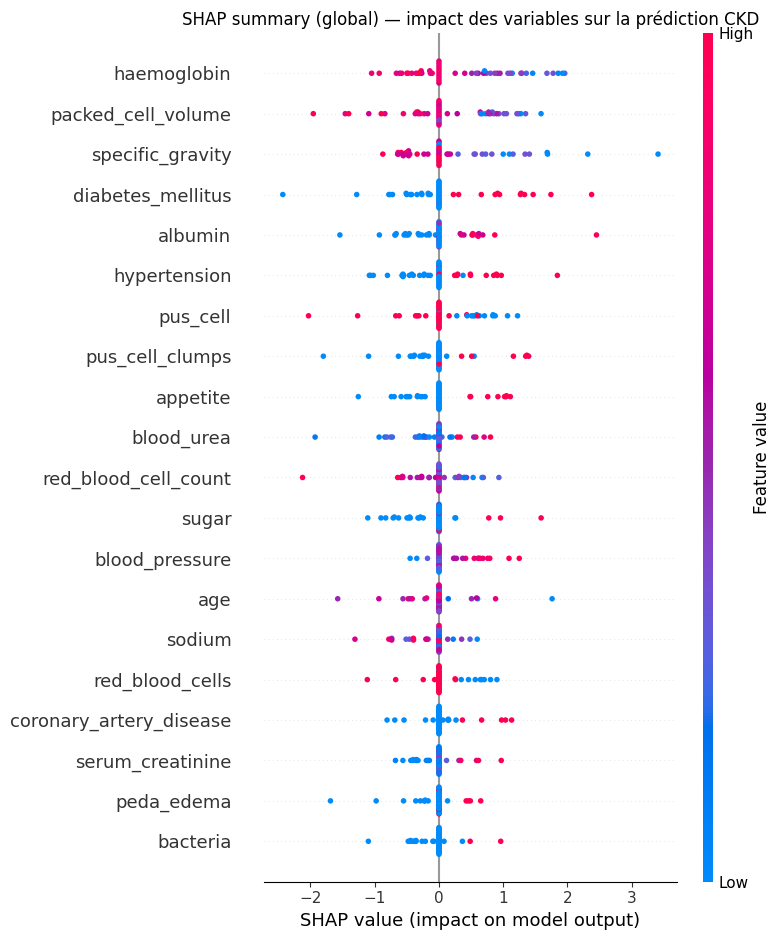

In [115]:
# Explication globale : summary plot sur un sous-ensemble du test (coûteux en temps)
X_test_sample = X_test_scaled.sample(min(50, len(X_test_scaled)), random_state=RANDOM_STATE)
shap_values_global = explainer_shap.shap_values(X_test_sample, nsamples=100)
# Avec predict_proba_ckd_shap, shap_values_global a shape (n_samples, n_features)
shap.summary_plot(shap_values_global, X_test_sample, feature_names=feature_names, show=False)
plt.title('SHAP summary (global) — impact des variables sur la prédiction CKD')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_shap_global.png'), bbox_inches='tight', dpi=150)
plt.show()